# syn1_Friedman: Default BART vs Parallel Tempering BART

This notebook uses diagnosis/pt/experiment.py to run multi-run, multi-chain experiments.
- Different runs: different train/test splits
- Same run, different chains: same split, different random seeds
- PT temperatures are selected by quick ladder search before each run

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path(os.getcwd()).resolve().parents[1]  # bart-playground root
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

notebook = "syn1_Friedman_pt"

In [2]:
import numpy as np

# Friedman (1991): 10 predictors, only the first 5 are relevant
rng = np.random.default_rng(42)
n_samples = 2000
noise_std = 1.0

X = rng.uniform(0.0, 1.0, size=(n_samples, 10)).astype(float)
eps = rng.normal(0.0, noise_std, size=n_samples)
y = (
    10.0 * np.sin(np.pi * X[:, 0] * X[:, 1])
    + 20.0 * (X[:, 2] - 0.5) ** 2
    + 10.0 * X[:, 3]
    + 5.0 * X[:, 4]
    + eps
)
y = np.asarray(y).reshape(-1)

X.shape, y.shape

((2000, 10), (2000,))

In [3]:
from experiment import run_parallel_experiments

ndpost = 10000
nskip = 5000
n_trees = 1

# You can scale these up for final experiments
n_runs = 5
n_chains = 5
n_jobs = 5

results = run_parallel_experiments(
    X=X,
    y=y,
    ndpost=ndpost,
    nskip=nskip,
    n_trees=n_trees,
    notebook=notebook,
    n_runs=n_runs,
    n_chains=n_chains,
    n_jobs=n_jobs,
    store_preds=True,
    n_test_points=100,
    swap_interval=50,
    ladder_target_rate=0.4,
    ladder_max_rounds=10,
    ladder_ndpost=500,
    ladder_nskip=100,
    ladder_repeats=3,
    ladder_search_points=500,
    ladder_initial_temperatures=(1.0, 2.0, 3.0, 5.0),
    store_dir="store",
    progress_print=True,
)

print(f"Finished. Stored CSV files under: {Path('store').resolve()}")

[RUN 0] start (1/5) | split_seed=42
[LADDER] start: n_points=500, rounds<=10, repeats=3, target_rate=0.4, init_temps=[1.0, 2.0, 3.0, 5.0]
[LADDER] round 1/10: n_temps=4, mean_rates=[0.6889, 0.8444, 0.7333]
[LADDER] stop: target reached or no valid rates. final_temps=[1.0, 2.0, 3.0, 5.0]
[LADDER] done: final n_temps=4
[RUN 0] ladder selected temps=[1.0, 2.0, 3.0, 5.0]
[RUN 0] chains start: n_chains=5


[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   2 out of   5 | elapsed:   51.4s remaining:  1.3min
[Parallel(n_jobs=5)]: Done   3 out of   5 | elapsed:   52.7s remaining:   35.1s
[Parallel(n_jobs=5)]: Done   5 out of   5 | elapsed:   54.5s finished


[RUN 0] done and saved to store
[RUN 1] start (2/5) | split_seed=43
[LADDER] start: n_points=500, rounds<=10, repeats=3, target_rate=0.4, init_temps=[1.0, 2.0, 3.0, 5.0]
[LADDER] round 1/10: n_temps=4, mean_rates=[0.6222, 0.7778, 0.6]
[LADDER] stop: target reached or no valid rates. final_temps=[1.0, 2.0, 3.0, 5.0]
[LADDER] done: final n_temps=4
[RUN 1] ladder selected temps=[1.0, 2.0, 3.0, 5.0]
[RUN 1] chains start: n_chains=5


[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   2 out of   5 | elapsed:   46.9s remaining:  1.2min
[Parallel(n_jobs=5)]: Done   3 out of   5 | elapsed:   47.3s remaining:   31.5s
[Parallel(n_jobs=5)]: Done   5 out of   5 | elapsed:   49.1s finished


[RUN 1] done and saved to store
[RUN 2] start (3/5) | split_seed=44
[LADDER] start: n_points=500, rounds<=10, repeats=3, target_rate=0.4, init_temps=[1.0, 2.0, 3.0, 5.0]
[LADDER] round 1/10: n_temps=4, mean_rates=[0.6, 0.7111, 0.6889]
[LADDER] stop: target reached or no valid rates. final_temps=[1.0, 2.0, 3.0, 5.0]
[LADDER] done: final n_temps=4
[RUN 2] ladder selected temps=[1.0, 2.0, 3.0, 5.0]
[RUN 2] chains start: n_chains=5


...

[RUN 2] done and saved to store
[RUN 3] start (4/5) | split_seed=45
[LADDER] start: n_points=500, rounds<=10, repeats=3, target_rate=0.4, init_temps=[1.0, 2.0, 3.0, 5.0]
[LADDER] round 1/10: n_temps=4, mean_rates=[0.6444, 0.8222, 0.6667]
[LADDER] stop: target reached or no valid rates. final_temps=[1.0, 2.0, 3.0, 5.0]
[LADDER] done: final n_temps=4
[RUN 3] ladder selected temps=[1.0, 2.0, 3.0, 5.0]
[RUN 3] chains start: n_chains=5


[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   2 out of   5 | elapsed:   39.5s remaining:   59.3s
[Parallel(n_jobs=5)]: Done   3 out of   5 | elapsed:   39.6s remaining:   26.4s
[Parallel(n_jobs=5)]: Done   5 out of   5 | elapsed:   43.1s finished


[RUN 3] done and saved to store
[RUN 4] start (5/5) | split_seed=46
[LADDER] start: n_points=500, rounds<=10, repeats=3, target_rate=0.4, init_temps=[1.0, 2.0, 3.0, 5.0]
[LADDER] round 1/10: n_temps=4, mean_rates=[0.6667, 0.8222, 0.7111]
[LADDER] stop: target reached or no valid rates. final_temps=[1.0, 2.0, 3.0, 5.0]
[LADDER] done: final n_temps=4
[RUN 4] ladder selected temps=[1.0, 2.0, 3.0, 5.0]
[RUN 4] chains start: n_chains=5


[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   2 out of   5 | elapsed:   41.0s remaining:  1.0min
[Parallel(n_jobs=5)]: Done   3 out of   5 | elapsed:   41.4s remaining:   27.6s
[Parallel(n_jobs=5)]: Done   5 out of   5 | elapsed:   43.3s finished


[RUN 4] done and saved to store
Finished. Stored CSV files under: C:\Users\ztykk\Phd\BART\bart-playground\diagnosis\pt_1tree\store


In [4]:
from pathlib import Path
import ast
import csv
import re

import numpy as np

STORE_DIR = Path("store")
setting_tag = globals().get("notebook")
meta_dir = STORE_DIR / "metadata"


def _load_numeric_csv(file_path: Path) -> np.ndarray:
    with open(file_path, "r", encoding="utf-8") as f:
        header_line = f.readline().strip()

    header_clean = header_line.lstrip("# ")
    match = re.search(r"original_shape=(.*)$", header_clean)
    if not match:
        raise ValueError(f"Missing original_shape header in {file_path}")

    original_shape = ast.literal_eval(match.group(1))
    if isinstance(original_shape, int):
        original_shape = (original_shape,)

    data = np.loadtxt(file_path, delimiter=",", comments="#")
    data = np.asarray(data)

    if len(original_shape) == 0:
        return data.reshape(())

    if len(original_shape) == 1:
        return data.reshape(-1).reshape(original_shape)

    return data.reshape(original_shape)


def _run_file(run_id: int, model: str, metric: str) -> Path:
    return STORE_DIR / metric / f"{setting_tag}__run{run_id:03d}__{model}__{metric}.csv"


def _subsample_file(run_id: int, suffix: str) -> Path:
    return STORE_DIR / suffix / f"{setting_tag}__run{run_id:03d}__{suffix}.csv"


meta_files = sorted(meta_dir.glob(f"{setting_tag}__run*.csv"))
if not meta_files:
    raise FileNotFoundError(
        f"No metadata files found for setting_tag={setting_tag!r} under {meta_dir.resolve()}"
    )

results = []
run_ids = []
n_chains_per_run = []

for file_path in meta_files:
    metadata = {}
    with open(file_path, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            metadata[row["key"]] = row["value"]

    match = re.search(r"__run(\d+)\.csv$", file_path.name)
    parsed_run_id = int(match.group(1)) if match else None

    if "run_id" in metadata:
        run_id = int(float(metadata["run_id"]))
    elif parsed_run_id is not None:
        run_id = parsed_run_id
    else:
        raise ValueError(f"Could not parse run id from file: {file_path.name}")

    if "split_seed" not in metadata:
        raise ValueError(f"Missing split_seed in metadata file: {file_path.name}")
    split_seed = int(float(metadata["split_seed"]))

    if "n_chains" not in metadata:
        raise ValueError(f"Missing n_chains in metadata file: {file_path.name}")
    n_chains_this_run = int(float(metadata["n_chains"]))

    run_ids.append(run_id)
    n_chains_per_run.append(n_chains_this_run)

    # Required for downstream comparison + plotting cells.
    required_files = [
        _run_file(run_id, "default", "preds"),
        _run_file(run_id, "pt", "preds"),
        _run_file(run_id, "default", "sigmas"),
        _run_file(run_id, "pt", "sigmas"),
        _subsample_file(run_id, "subsample_X_test"),
        _subsample_file(run_id, "subsample_y_test"),
    ]
    for required_file in required_files:
        if not required_file.exists():
            raise FileNotFoundError(f"Missing required results file: {required_file}")

    run_result = {
        "run_id": run_id,
        "split_seed": split_seed,
        "subsample": {
            "X_test": _load_numeric_csv(_subsample_file(run_id, "subsample_X_test")),
            "y_test": _load_numeric_csv(_subsample_file(run_id, "subsample_y_test")),
        },
        "default": {
            "preds": _load_numeric_csv(_run_file(run_id, "default", "preds")),
            "sigmas": _load_numeric_csv(_run_file(run_id, "default", "sigmas")),
        },
        "pt": {
            "preds": _load_numeric_csv(_run_file(run_id, "pt", "preds")),
            "sigmas": _load_numeric_csv(_run_file(run_id, "pt", "sigmas")),
        },
        "metadata": {
            "n_chains": n_chains_this_run,
        },
    }

    # Optional metrics (loaded when present).
    optional_metrics = ["rmses", "leaves", "depths", "subsample_rmse", "subsample_crps", "coverage"]
    for metric in optional_metrics:
        default_path = _run_file(run_id, "default", metric)
        pt_path = _run_file(run_id, "pt", metric)
        if default_path.exists():
            run_result["default"][metric] = _load_numeric_csv(default_path)
        if pt_path.exists():
            run_result["pt"][metric] = _load_numeric_csv(pt_path)

    swap_path = _run_file(run_id, "pt", "swap_accept_rates")
    if swap_path.exists():
        run_result["pt"]["swap_accept_rates"] = _load_numeric_csv(swap_path)

    results.append(run_result)

results = sorted(results, key=lambda r: r["run_id"])
run_ids = [int(r["run_id"]) for r in results]
n_runs = len(results)
unique_chain_counts = sorted(set(n_chains_per_run))

if len(unique_chain_counts) == 1:
    n_chains = unique_chain_counts[0]
    print(f"Loaded results from disk: n_runs={n_runs}, n_chains={n_chains}")
else:
    n_chains = None
    print(f"Loaded results from disk: n_runs={n_runs}, n_chains varies by run")

print("run_ids:", run_ids)
print("n_chains_per_run:", n_chains_per_run)

# Reusable across later cells in this session after reopening notebook.
results_manifest = {
    "setting_tag": setting_tag,
    "run_ids": run_ids,
    "n_runs": n_runs,
    "n_chains": n_chains,
    "n_chains_per_run": n_chains_per_run,
    "metadata_files": [str(p) for p in meta_files],
}


Loaded results from disk: n_runs=5, n_chains=5
run_ids: [0, 1, 2, 3, 4]
n_chains_per_run: [5, 5, 5, 5, 5]


In [5]:
import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split

# Used only for downstream plots (PCA/trace).
SELECT_RUN_ID = 0
SELECT_CHAIN_ID = 0
TABPFN_RANDOM_STATE = 42

def crps_from_samples(samples, y_true):
    """CRPS from posterior samples.

    samples: (n_points, n_samples)
    y_true:  (n_points,)
    """
    n_points, n_samples = samples.shape
    term1 = np.mean(np.abs(samples - y_true[:, None]), axis=1)
    samples_sorted = np.sort(samples, axis=1)
    k = np.arange(1, n_samples + 1)
    coeffs = (2 * k - n_samples - 1)[None, :]
    term2 = np.sum(coeffs * samples_sorted, axis=1) / (n_samples ** 2)
    return term1 - term2

def ensure_point_by_sample(arr, n_points):
    """Ensure array is (n_points, n_samples)."""
    arr = np.asarray(arr, dtype=float)
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D array, got shape={arr.shape}")
    if arr.shape[0] == n_points:
        return arr
    if arr.shape[1] == n_points:
        return arr.T
    raise ValueError(f"Could not align samples with n_points={n_points}, shape={arr.shape}")

from tabpfn import TabPFNRegressor

rows_rmse = []
rows_crps = []
run_cache = {}

for run in results:
    run_id = int(run["run_id"])
    split_seed = int(run["split_seed"])

    # Keep split identical across compared methods inside each run.
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=split_seed)
    X_test_sub = np.asarray(run["subsample"]["X_test"], dtype=float)
    y_test_sub = np.asarray(run["subsample"]["y_test"], dtype=float).reshape(-1)

    # ---- Default BART: average metrics over chains ----
    default_chain_rmse = []
    default_chain_crps = []
    for chain_pred in run["default"]["preds"]:
        samples = ensure_point_by_sample(chain_pred, n_points=y_test_sub.shape[0])
        pred_mean = np.mean(samples, axis=1)
        default_chain_rmse.append(root_mean_squared_error(y_test_sub, pred_mean))
        default_chain_crps.append(float(np.mean(crps_from_samples(samples, y_test_sub))))

    # ---- PT BART: average metrics over chains ----
    pt_chain_rmse = []
    pt_chain_crps = []
    for chain_pred in run["pt"]["preds"]:
        samples = ensure_point_by_sample(chain_pred, n_points=y_test_sub.shape[0])
        pred_mean = np.mean(samples, axis=1)
        pt_chain_rmse.append(root_mean_squared_error(y_test_sub, pred_mean))
        pt_chain_crps.append(float(np.mean(crps_from_samples(samples, y_test_sub))))

    # ---- TabPFN: point prediction only (once per run) ----
    tabpfn_model = TabPFNRegressor(
        random_state=TABPFN_RANDOM_STATE,
        ignore_pretraining_limits=True,
    )
    tabpfn_model.fit(X_train, y_train)
    tabpfn_mean = np.asarray(tabpfn_model.predict(X_test_sub), dtype=float).reshape(-1)
    tabpfn_rmse = root_mean_squared_error(y_test_sub, tabpfn_mean)

    rows_rmse.append(
        {
            "run_id": run_id,
            "default bart": float(np.mean(default_chain_rmse)),
            "pt": float(np.mean(pt_chain_rmse)),
            "tabpfn": float(tabpfn_rmse),
        }
    )
    rows_crps.append(
        {
            "run_id": run_id,
            "default bart": float(np.mean(default_chain_crps)),
            "pt": float(np.mean(pt_chain_crps)),
        }
    )

    run_cache[run_id] = {
        "selected_run": run,
        "split_seed": split_seed,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "X_test_sub": X_test_sub,
        "y_test_sub": y_test_sub,
        "tabpfn_mean": tabpfn_mean,
    }

rmse_table = pd.DataFrame(rows_rmse).sort_values("run_id").set_index("run_id")
crps_table = pd.DataFrame(rows_crps).sort_values("run_id").set_index("run_id")

print("RMSE table (rows=runs, cols=models):")
display(rmse_table)
print("\nCRPS table (rows=runs, cols=models; tabpfn excluded):")
display(crps_table)

# Variables for downstream plotting cells.
if SELECT_RUN_ID not in run_cache:
    raise ValueError(f"SELECT_RUN_ID={SELECT_RUN_ID} not found in available runs: {sorted(run_cache.keys())}")

selected_run = run_cache[SELECT_RUN_ID]["selected_run"]
X_train = run_cache[SELECT_RUN_ID]["X_train"]
X_test = run_cache[SELECT_RUN_ID]["X_test"]
y_train = run_cache[SELECT_RUN_ID]["y_train"]
y_test = run_cache[SELECT_RUN_ID]["y_test"]
X_test_sub = run_cache[SELECT_RUN_ID]["X_test_sub"]
y_test_sub = run_cache[SELECT_RUN_ID]["y_test_sub"]
tabpfn_mean = run_cache[SELECT_RUN_ID]["tabpfn_mean"]

default_samples = ensure_point_by_sample(
    selected_run["default"]["preds"][SELECT_CHAIN_ID],
    n_points=y_test_sub.shape[0],
)
pt_samples = ensure_point_by_sample(
    selected_run["pt"]["preds"][SELECT_CHAIN_ID],
    n_points=y_test_sub.shape[0],
)

rmse_default = root_mean_squared_error(y_test_sub, np.mean(default_samples, axis=1))
rmse_pt = root_mean_squared_error(y_test_sub, np.mean(pt_samples, axis=1))
rmse_tabpfn = root_mean_squared_error(y_test_sub, tabpfn_mean)
crps_default = float(np.mean(crps_from_samples(default_samples, y_test_sub)))
crps_pt = float(np.mean(crps_from_samples(pt_samples, y_test_sub)))

print(f"\nFor downstream plots: selected run={SELECT_RUN_ID}, chain={SELECT_CHAIN_ID}")
print("Shapes -> default:", default_samples.shape, "pt:", pt_samples.shape, "tabpfn_mean:", tabpfn_mean.shape)

RMSE table (rows=runs, cols=models):


,default bart,pt,tabpfn
run_id,,,
0,2.735559,2.958790,1.091399
1,2.614428,2.911014,1.051044
2,2.856909,2.794868,1.116398
3,2.684175,2.926562,1.026928
4,2.731043,3.020427,1.010453



CRPS table (rows=runs, cols=models; tabpfn excluded):


,default bart,pt
run_id,,
0,1.908271,2.004123
1,1.829219,1.974483
2,1.978011,1.797406
3,1.897353,1.913652
4,1.890664,1.953206



For downstream plots: selected run=0, chain=0
Shapes -> default: (100, 10000) pt: (100, 10000) tabpfn_mean: (100,)


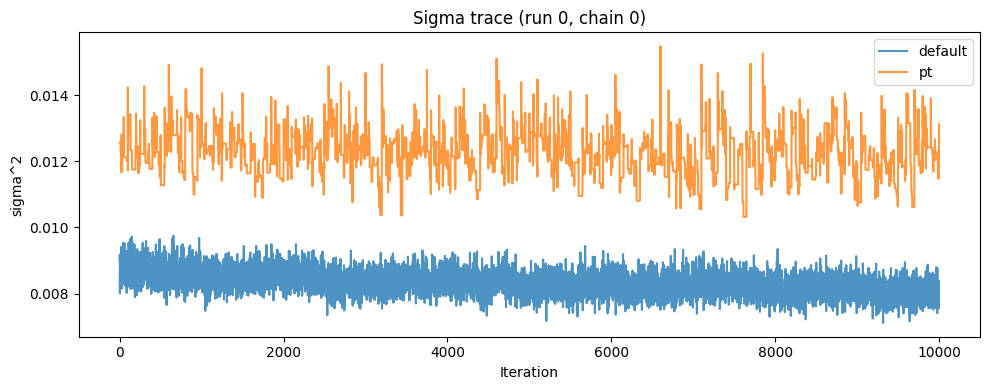

In [6]:
import matplotlib.pyplot as plt

# Sigma trace for selected run/chain
sigma_default = np.asarray(selected_run["default"]["sigmas"][SELECT_CHAIN_ID]).reshape(-1)
sigma_pt = np.asarray(selected_run["pt"]["sigmas"][SELECT_CHAIN_ID]).reshape(-1)

plt.figure(figsize=(10, 4))
plt.plot(sigma_default, label="default", alpha=0.8)
plt.plot(sigma_pt, label="pt", alpha=0.8)
plt.xlabel("Iteration")
plt.ylabel("sigma^2")
plt.title(f"Sigma trace (run {SELECT_RUN_ID}, chain {SELECT_CHAIN_ID})")
plt.legend()
plt.tight_layout()
plt.show()

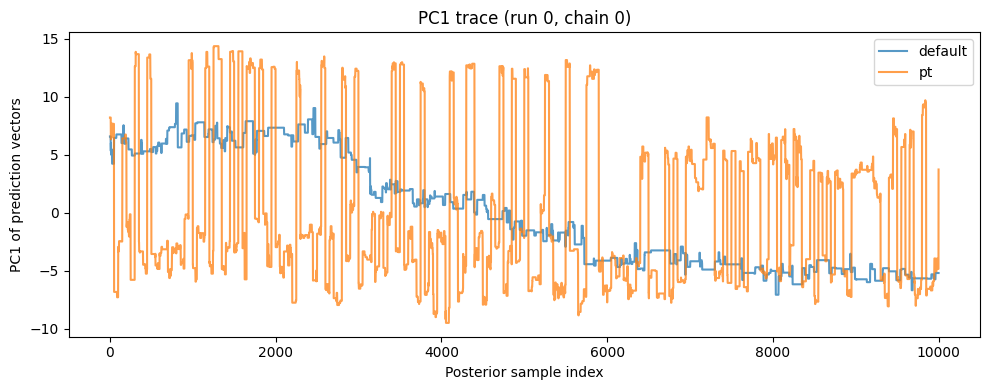

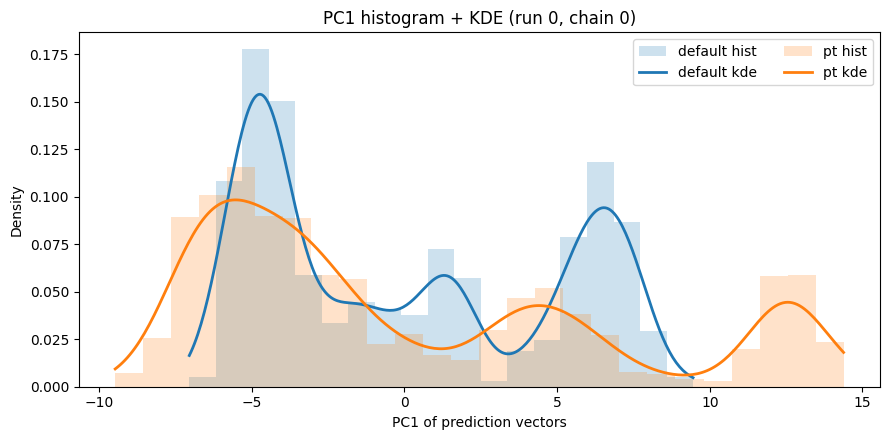

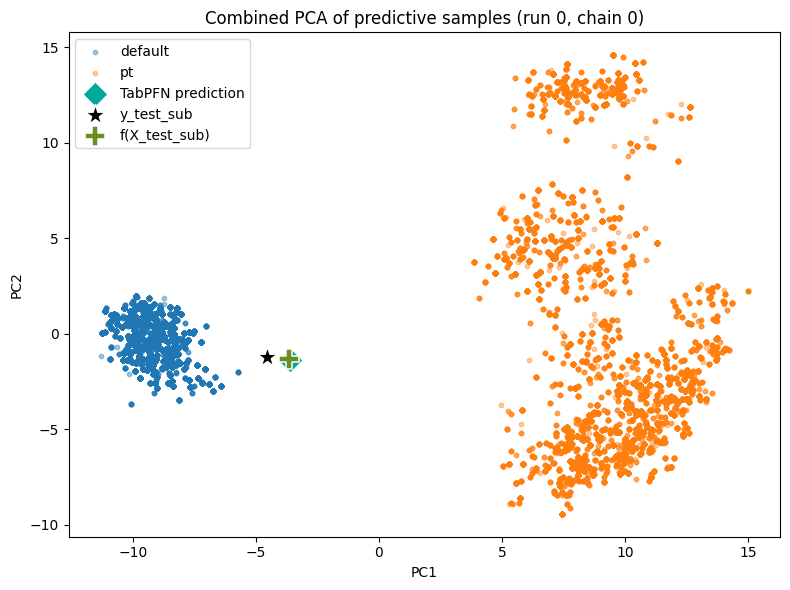

In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# Build sample vectors: each posterior draw is one vector over test points.
# Input shapes are (n_points, n_samples); convert to (n_samples, n_points).
X_default_vec = default_samples.T
X_pt_vec = pt_samples.T

# PC1 trace plot (default and pt only).
pc1_default = PCA(n_components=1).fit_transform(X_default_vec)[:, 0]
pc1_pt = PCA(n_components=1).fit_transform(X_pt_vec)[:, 0]

plt.figure(figsize=(10, 4))
plt.plot(pc1_default, label="default", alpha=0.75)
plt.plot(pc1_pt, label="pt", alpha=0.75)
plt.xlabel("Posterior sample index")
plt.ylabel("PC1 of prediction vectors")
plt.title(f"PC1 trace (run {SELECT_RUN_ID}, chain {SELECT_CHAIN_ID})")
plt.legend()
plt.tight_layout()
plt.show()

# PC1 histogram + KDE in one figure.
plt.figure(figsize=(9, 4.5))
for arr, name, color in [
    (pc1_default, "default", "tab:blue"),
    (pc1_pt, "pt", "tab:orange"),
]:
    plt.hist(arr, bins="auto", density=True, alpha=0.22, color=color, label=f"{name} hist")
    x_grid = np.linspace(np.min(arr), np.max(arr), 300)
    kde = gaussian_kde(arr)
    plt.plot(x_grid, kde(x_grid), color=color, linewidth=2.0, label=f"{name} kde")

plt.xlabel("PC1 of prediction vectors")
plt.ylabel("Density")
plt.title(f"PC1 histogram + KDE (run {SELECT_RUN_ID}, chain {SELECT_CHAIN_ID})")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

# Combined PCA: PC1 vs PC2 scatter for default and pt predictive distributions.
X_combined = np.vstack([X_default_vec, X_pt_vec])
labels = np.array(
    ["default"] * len(X_default_vec)
    + ["pt"] * len(X_pt_vec)
)

pca2 = PCA(n_components=2)
pc2 = pca2.fit_transform(X_combined)

plt.figure(figsize=(8, 6))
for name, color in [("default", "tab:blue"), ("pt", "tab:orange")]:
    mask = labels == name
    plt.scatter(pc2[mask, 0], pc2[mask, 1], s=10, alpha=0.4, c=color, label=name)

# Draw tabpfn point prediction, y_test_sub and f(X_test_sub) only on this plot.
tabpfn_mean_proj = pca2.transform(tabpfn_mean.reshape(1, -1))[0]
y_proj = pca2.transform(y_test_sub.reshape(1, -1))[0]
f_test_sub = (
    10.0 * np.sin(np.pi * X_test_sub[:, 0] * X_test_sub[:, 1])
    + 20.0 * (X_test_sub[:, 2] - 0.5) ** 2
    + 10.0 * X_test_sub[:, 3]
    + 5.0 * X_test_sub[:, 4]
)
f_proj = pca2.transform(f_test_sub.reshape(1, -1))[0]

plt.scatter(
    tabpfn_mean_proj[0],
    tabpfn_mean_proj[1],
    s=170,
    c="#00A79D",
    marker="D",
    edgecolors="white",
    linewidths=1.2,
    zorder=7,
    label="TabPFN prediction",
)
plt.scatter(
    y_proj[0],
    y_proj[1],
    s=240,
    c="black",
    marker="*",
    edgecolors="white",
    linewidths=1.1,
    zorder=8,
    label="y_test_sub",
)
plt.scatter(
    f_proj[0],
    f_proj[1],
    s=220,
    c="#6B8E23",
    marker="P",
    edgecolors="white",
    linewidths=1.1,
    zorder=8,
    label="f(X_test_sub)",
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Combined PCA of predictive samples (run {SELECT_RUN_ID}, chain {SELECT_CHAIN_ID})")
plt.legend()
plt.tight_layout()
plt.show()